In [1]:
import re
from datetime import datetime
import numpy as np

In [2]:
def extract_data(file_path):
    data = {}
    with open(file_path, 'r') as file:
        for line in file:
            # Match the log line with the required pattern
            match = re.search(r'(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d{3}) - root - INFO - .*?step:\s+(\d+).*?memory:\s+([\d.]+GiB).*?tps:\s+([\d.]+).*?tflops:\s+([\d.]+)', line)
            if match:
                timestamp = match.group(1)
                step = int(match.group(2))
                memory = match.group(3)
                tps = float(match.group(4))
                tflops = float(match.group(5))
                
                # Only store data for steps 1 to 10
                if 1 <= step <= 10:
                    if step not in data:
                        data[step] = {
                            'timestamp': timestamp,
                            'memory': memory,
                            'tps': tps,
                            'tflops': tflops
                        }
    return data

In [10]:
import csv

# Example usage

def store_data(file_path_base, experiment, file_name, output_file):
    file_path = file_path_base + experiment + "/" + file_name

    result = extract_data(file_path)

    print(experiment)

    for step in sorted(result.keys()):
        print(f"Step {step}: {result[step]}")

    # Calculate per step latency and average latency with standard deviation
    if 4 in result and 10 in result:
        time_format = "%Y-%m-%d %H:%M:%S,%f"
        step_times = []

        for step in range(4, 11):
            if step in result:
                step_time = datetime.strptime(result[step]['timestamp'], time_format)
                step_times.append((step, step_time))

        # Calculate per step latency
        per_step_latencies = []
        for i in range(1, len(step_times)):
            step_diff = step_times[i][0] - step_times[i - 1][0]
            time_diff = (step_times[i][1] - step_times[i - 1][1]).total_seconds()
            latency = time_diff / step_diff
            per_step_latencies.append(latency)
            print(f"Latency between step {step_times[i - 1][0]} and step {step_times[i][0]}: {latency:.3f} seconds")

        # Calculate average latency and standard deviation
        avg_latency = np.mean(per_step_latencies)
        std_latency = np.std(per_step_latencies)
        min_latency = np.min(per_step_latencies)
        print(f"{experiment}, avg step latency: {avg_latency:.3f} seconds, std: {std_latency:.3f} seconds, min: {min_latency:.3f} seconds")
        # Save step latency and standard deviation to a CSV file
        
        with open(output_file, mode='a', newline='') as file:  # Open in append mode
            writer = csv.writer(file)
            writer.writerow([experiment, min_latency, avg_latency, std_latency])

        print(f"Latency data appended to {output_file}")

        print(f"Latency data saved to {output_file}")
    else:
        print("Step 4 or Step 10 data is missing.")

In [11]:
import os

file_path_base = '<path-to-opus>/Opus/torchtitan/opus-test/dp-8-pp-2-tp-4-pm-8b/'


latency = [0, 10, 50, 100, 250, 500, 750, 1000]
experiments =  ["output-opus-no-ctl-dp8"] + [f"output-opus-l_{l}-baseline-dp8" for l in latency]
file_name = [
    next(
        (f for f in os.listdir(os.path.join(file_path_base, exp)) if f.startswith("torchrun_nid") and f.endswith(".ans")),
        None
    )
    for exp in experiments
]

output_file = 'latency_results_baseline.csv'

# Write the CSV header if the file does not exist or is empty
# Clean the CSV file before writing
if os.path.exists(output_file):
    with open(output_file, mode='w', newline='') as file:
        file.truncate(0)
if not os.path.exists(output_file) or os.stat(output_file).st_size == 0:
    with open(output_file, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Experiment', 'Min latency (s)', 'Average Latency (s)', 'Standard Deviation (s)'])
for experiment, file_name in zip(experiments, file_name):
    store_data(file_path_base, experiment, file_name, output_file)

output-opus-no-ctl-dp8
Step 1: {'timestamp': '2026-02-02 17:26:45,009', 'memory': '31.11GiB', 'tps': 311.0, 'tflops': 18.01}
Step 2: {'timestamp': '2026-02-02 17:26:59,481', 'memory': '31.11GiB', 'tps': 567.0, 'tflops': 32.81}
Step 3: {'timestamp': '2026-02-02 17:27:14,005', 'memory': '31.11GiB', 'tps': 564.0, 'tflops': 32.67}
Step 4: {'timestamp': '2026-02-02 17:27:28,435', 'memory': '31.11GiB', 'tps': 568.0, 'tflops': 32.89}
Step 5: {'timestamp': '2026-02-02 17:27:42,896', 'memory': '31.11GiB', 'tps': 567.0, 'tflops': 32.81}
Step 6: {'timestamp': '2026-02-02 17:27:57,314', 'memory': '31.11GiB', 'tps': 568.0, 'tflops': 32.91}
Step 7: {'timestamp': '2026-02-02 17:28:11,604', 'memory': '31.11GiB', 'tps': 573.0, 'tflops': 33.21}
Step 8: {'timestamp': '2026-02-02 17:28:25,966', 'memory': '31.11GiB', 'tps': 571.0, 'tflops': 33.04}
Step 9: {'timestamp': '2026-02-02 17:28:40,695', 'memory': '31.11GiB', 'tps': 557.0, 'tflops': 32.23}
Step 10: {'timestamp': '2026-02-02 17:28:55,426', 'memory':

In [16]:
import os

file_path_base = '<path-to-opus>/Opus/torchtitan/opus-test/dp-8-pp-2-tp-4-pm-8b/'


latency = [0, 10, 50, 100, 250, 500, 750, 1000]
experiments =  ["output-opus-no-ctl-dp8"] + [f"output-opus-l_{l}-provision-dp8" for l in latency]
file_name = [
    next(
        (f for f in os.listdir(os.path.join(file_path_base, exp)) if f.startswith("torchrun_nid") and f.endswith(".ans")),
        None
    )
    for exp in experiments
]

output_file = 'latency_results_provision.csv'

# Write the CSV header if the file does not exist or is empty
# Clean the CSV file before writing
if os.path.exists(output_file):
    with open(output_file, mode='w', newline='') as file:
        file.truncate(0)
if not os.path.exists(output_file) or os.stat(output_file).st_size == 0:
    with open(output_file, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Experiment', 'Min latency (s)', 'Average Latency (s)', 'Standard Deviation (s)'])
for experiment, file_name in zip(experiments, file_name):
    store_data(file_path_base, experiment, file_name, output_file)

output-opus-no-ctl-dp8
Step 1: {'timestamp': '2026-02-02 17:26:45,009', 'memory': '31.11GiB', 'tps': 311.0, 'tflops': 18.01}
Step 2: {'timestamp': '2026-02-02 17:26:59,481', 'memory': '31.11GiB', 'tps': 567.0, 'tflops': 32.81}
Step 3: {'timestamp': '2026-02-02 17:27:14,005', 'memory': '31.11GiB', 'tps': 564.0, 'tflops': 32.67}
Step 4: {'timestamp': '2026-02-02 17:27:28,435', 'memory': '31.11GiB', 'tps': 568.0, 'tflops': 32.89}
Step 5: {'timestamp': '2026-02-02 17:27:42,896', 'memory': '31.11GiB', 'tps': 567.0, 'tflops': 32.81}
Step 6: {'timestamp': '2026-02-02 17:27:57,314', 'memory': '31.11GiB', 'tps': 568.0, 'tflops': 32.91}
Step 7: {'timestamp': '2026-02-02 17:28:11,604', 'memory': '31.11GiB', 'tps': 573.0, 'tflops': 33.21}
Step 8: {'timestamp': '2026-02-02 17:28:25,966', 'memory': '31.11GiB', 'tps': 571.0, 'tflops': 33.04}
Step 9: {'timestamp': '2026-02-02 17:28:40,695', 'memory': '31.11GiB', 'tps': 557.0, 'tflops': 32.23}
Step 10: {'timestamp': '2026-02-02 17:28:55,426', 'memory':

The previous result show that this experiment has 12 reconfigurations per step

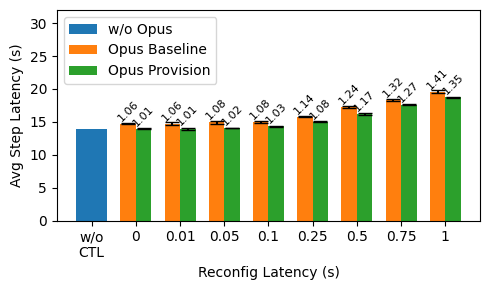

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Ensure the experiments are plotted in the specified order
experiments_1 = [
    'output-opus-l_0-baseline-dp8',
    'output-opus-l_10-baseline-dp8',
    'output-opus-l_50-baseline-dp8',
    'output-opus-l_100-baseline-dp8',
    'output-opus-l_250-baseline-dp8',
    'output-opus-l_500-baseline-dp8',
    'output-opus-l_750-baseline-dp8',
    'output-opus-l_1000-baseline-dp8',
]

experiments_2 = [
    'output-opus-l_0-provision-dp8',
    'output-opus-l_10-provision-dp8',
    'output-opus-l_50-provision-dp8',
    'output-opus-l_100-provision-dp8',
    'output-opus-l_250-provision-dp8',
    'output-opus-l_500-provision-dp8',
    'output-opus-l_750-provision-dp8',
    'output-opus-l_1000-provision-dp8',
]

xlabels = ['w/o\nCTL', '0', '0.01', '0.05', '0.1', '0.25', '0.5', '0.75', '1']

latency = [0, 10, 50, 100, 250, 500, 750, 1000]

baseline = 13.855
estimated = [baseline] + [baseline + 6 * 0.001 * l for l in latency]

# Read the first CSV file
output_file = 'latency_results_baseline.csv'
data = pd.read_csv(output_file)

# Group by Experiment and calculate the mean of Average Latency and Standard Deviation
data = data[data['Experiment'].isin(experiments_1)].copy()

data['Experiment'] = pd.Categorical(
    data['Experiment'],
    categories=experiments_1,
    ordered=True
)
grouped_data = data.sort_values('Experiment')
grouped_data = data.sort_values('Experiment')

# Read the second CSV file
output_file_2 = 'latency_results_provision.csv'
data_2 = pd.read_csv(output_file_2)
data_2 = data_2[data_2['Experiment'].isin(experiments_2)].copy()

# Group by Experiment and calculate the mean of Average Latency and Standard Deviation for the second file
data_2['Experiment'] = pd.Categorical(data_2['Experiment'], categories=experiments_2, ordered=True)
grouped_data_2 = data_2.sort_values('Experiment')

# Plot the data
plt.figure(figsize=(5, 3))
x = np.arange(len(xlabels))

bar_width = 0.35

plt.bar(
    x[0],
    baseline,
    bar_width * 2,
    label='w/o Opus'
)

# --------------------
# Remaining 10 categories: paired bars
# --------------------
plt.bar(
    x[1:] - bar_width / 2,
    grouped_data['Average Latency (s)'],
    bar_width,
    yerr=grouped_data['Standard Deviation (s)'],
    capsize=5,
    label='Opus Baseline'
)

plt.bar(
    x[1:] + bar_width / 2,
    grouped_data_2['Average Latency (s)'],
    bar_width,
    yerr=grouped_data_2['Standard Deviation (s)'],
    capsize=5,
    label='Opus Provision'
)

# Add a 1.x overhead on the top number
for i, (baseline_latency, provision_latency) in enumerate(zip(grouped_data['Average Latency (s)'], grouped_data_2['Average Latency (s)'])):
    plt.text(
        x[i + 1] - bar_width / 2,
        baseline_latency + 0.1,
        f"{baseline_latency / baseline:.2f}",
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=45  # Tilt the number by 45 degrees
    )
    plt.text(
        x[i + 1] + bar_width / 2,
        provision_latency + 0.1,
        f"{provision_latency / baseline:.2f}",
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=45  # Tilt the number by 45 degrees
    )

# plt.plot(
#     xlabels, 
#     estimated, 
#     marker='o', 
#     markersize=4,  # Make the dot smaller
#     linestyle='dashed', 
#     linewidth=1,  # Make the line thinner
#     label='Estimated'
# )
# Add labels and legend
plt.xticks(x, xlabels)
plt.xlabel('Reconfig Latency (s)')
plt.ylabel('Avg Step Latency (s)')
plt.ylim(0, 32)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

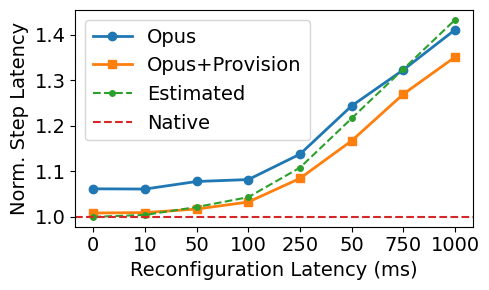

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
]

fontsize = 14

experiments_1 = [
    'output-opus-l_0-baseline-dp8',
    'output-opus-l_10-baseline-dp8',
    'output-opus-l_50-baseline-dp8',
    'output-opus-l_100-baseline-dp8',
    'output-opus-l_250-baseline-dp8',
    'output-opus-l_500-baseline-dp8',
    'output-opus-l_750-baseline-dp8',
    'output-opus-l_1000-baseline-dp8',
]

experiments_2 = [
    'output-opus-l_0-provision-dp8',
    'output-opus-l_10-provision-dp8',
    'output-opus-l_50-provision-dp8',
    'output-opus-l_100-provision-dp8',
    'output-opus-l_250-provision-dp8',
    'output-opus-l_500-provision-dp8',
    'output-opus-l_750-provision-dp8',
    'output-opus-l_1000-provision-dp8',
]

xlabels = ['0', '10', '50', '100', '250', '50', '750', '1000']
latency = [0, 10, 50, 100, 250, 500, 750, 1000]

baseline = 13.855
estimated = [baseline + 6 * 0.001 * l for l in latency]

# ---- Load data ----
data = pd.read_csv('latency_results_baseline.csv')
data = data[data['Experiment'].isin(experiments_1)].copy()
data['Experiment'] = pd.Categorical(data['Experiment'], categories=experiments_1, ordered=True)
grouped_data = data.sort_values('Experiment')

data_2 = pd.read_csv('latency_results_provision.csv')
data_2 = data_2[data_2['Experiment'].isin(experiments_2)].copy()
data_2['Experiment'] = pd.Categorical(data_2['Experiment'], categories=experiments_2, ordered=True)
grouped_data_2 = data_2.sort_values('Experiment')

# ---- Plot ----
plt.figure(figsize=(5, 3))
x = np.arange(len(xlabels))

# ---- Lines including baseline at x=0 ----
opus_baseline_line = grouped_data['Average Latency (s)'].tolist()
opus_provision_line = grouped_data_2['Average Latency (s)'].tolist()

plt.plot(x, [a / baseline for a in opus_baseline_line], marker='o', linewidth=2, label='Opus', color=colors[0])
plt.plot(x, [b / baseline for b in opus_provision_line], marker='s', linewidth=2, label='Opus+Provision', color=colors[1])

# ---- Estimated dashed line ----
plt.plot(
    x,
    [e / baseline for e in estimated],
    linestyle='dashed',
    linewidth=1.5,
    marker='o',
    markersize=4,
    label='Estimated',
    color=colors[2]
)

# ---- Horizontal dashed baseline ----
plt.axhline(y=1, linestyle='dashed', linewidth=1.5, label='Native', color=colors[3])

# ---- Overhead annotations (skip x=0) ----
# for i, (base_lat, prov_lat) in enumerate(zip(
#     grouped_data['Average Latency (s)'],
#     grouped_data_2['Average Latency (s)']
# )):
#     plt.text(x[i + 1], base_lat + 0.1, f"{base_lat / baseline:.2f}",
#              ha='center', fontsize=8, rotation=45)
#     plt.text(x[i + 1], prov_lat + 0.1, f"{prov_lat / baseline:.2f}",
#              ha='center', fontsize=8, rotation=45)

# ---- Labels ----
plt.xticks(x, xlabels, fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.xlabel('Reconfiguration Latency (ms)', fontsize=fontsize)
plt.ylabel('Norm. Step Latency', fontsize=fontsize)
# plt.ylim(13, 21)
plt.legend(loc='upper left', fontsize=fontsize)
plt.savefig('llama3-3d-64.pdf', format="pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()


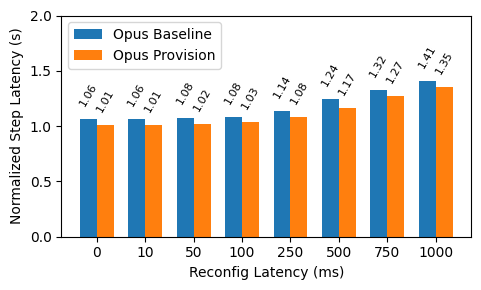

In [18]:


plt.figure(figsize=(5, 3))

xlabels = ['0', '10', '50', '100', '250', '500', '750', '1000']
x = np.arange(len(xlabels))

# plt.bar(
#     x[0],
#     baseline,
#     bar_width * 2,
#     label='w/o Opus'
# )

# --------------------
# Remaining 10 categories: paired bars
# --------------------
plt.bar(
    x - bar_width / 2,
    grouped_data['Average Latency (s)'] / baseline,
    bar_width,
    # yerr=grouped_data['Standard Deviation (s)'],
    capsize=5,
    label='Opus Baseline'
)

plt.bar(
    x + bar_width / 2,
    grouped_data_2['Average Latency (s)'] / baseline,
    bar_width,
    # yerr=grouped_data_2['Standard Deviation (s)'],
    capsize=5,
    label='Opus Provision'
)

# Add a 1.x overhead on the top number
for i, (baseline_latency, provision_latency) in enumerate(zip(grouped_data['Average Latency (s)'], grouped_data_2['Average Latency (s)'])):
    plt.text(
        x[i] - bar_width / 2,
        baseline_latency / baseline + 0.1,
        f"{baseline_latency / baseline:.2f}",
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=60  # Tilt the number by 45 degrees
    )
    plt.text(
        x[i] + bar_width / 2,
        provision_latency / baseline + 0.1,
        f"{provision_latency / baseline:.2f}",
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=60  # Tilt the number by 45 degrees
    )

# plt.plot(
#     xlabels, 
#     estimated, 
#     marker='o', 
#     markersize=4,  # Make the dot smaller
#     linestyle='dashed', 
#     linewidth=1,  # Make the line thinner
#     label='Estimated'
# )
# Add labels and legend
plt.xticks(x, xlabels)
plt.xlabel('Reconfig Latency (ms)')
plt.ylabel('Normalized Step Latency (s)')
plt.ylim(0, 2)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

#TODO I recommend changing X axis to milliseconds and going up to 500 milliseconds